In [1]:
import os
print(os.getcwd())
print(os.listdir("data"))

C:\Users\PC\OneDrive\Desktop\FUTURE_ML_01\TASK_02_Support_Ticket_Classification
['customer_support_tickets.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv("data/customer_support_tickets.csv")

print(df.shape)
df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [5]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [8]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [9]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [10]:
df["Ticket Priority"].value_counts()


Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

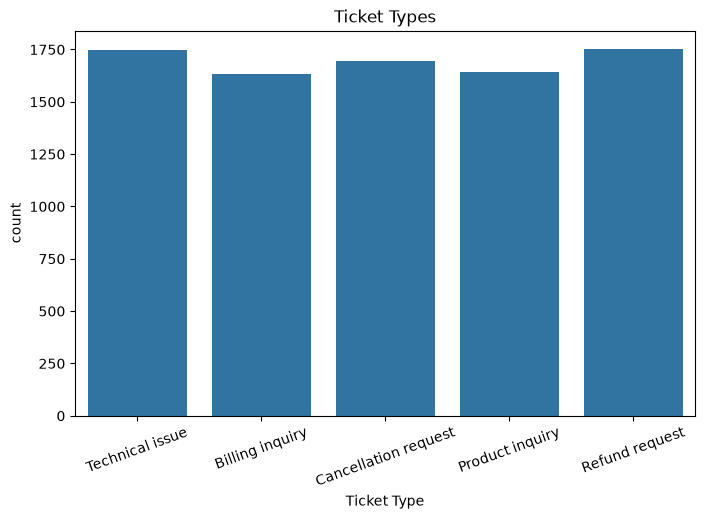

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Ticket Type")
plt.title("Ticket Types")
plt.xticks(rotation=20)
plt.show()

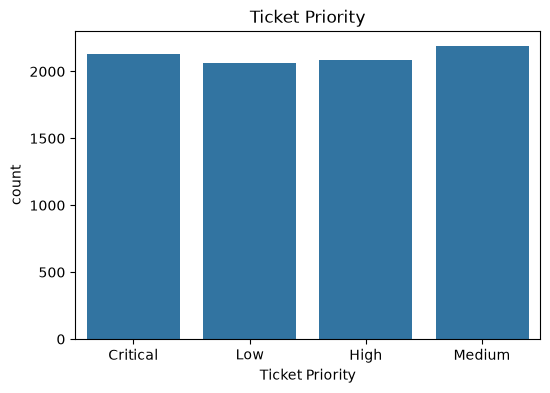

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Ticket Priority")
plt.title("Ticket Priority")
plt.show()

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [15]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [16]:
df.describe(include="all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,asmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 01:21:19,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [17]:
df.columns.tolist()

['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating']

In [18]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [19]:
df["Ticket Priority"].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [20]:
df["Ticket Status"].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

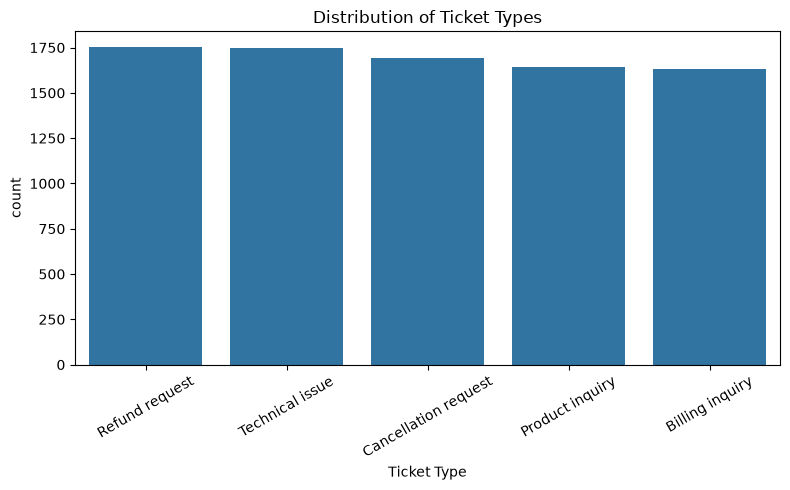

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ticket Type",
    order=df["Ticket Type"].value_counts().index
)

plt.title("Distribution of Ticket Types")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("images/ticket_type_distribution.png")
plt.show()

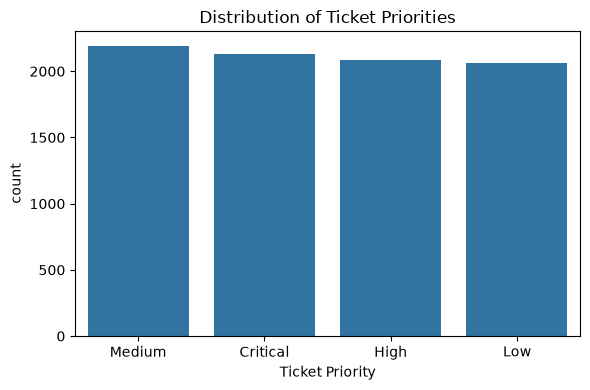

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Ticket Priority",
    order=df["Ticket Priority"].value_counts().index
)

plt.title("Distribution of Ticket Priorities")
plt.tight_layout()

plt.savefig("images/ticket_priority_distribution.png")
plt.show()

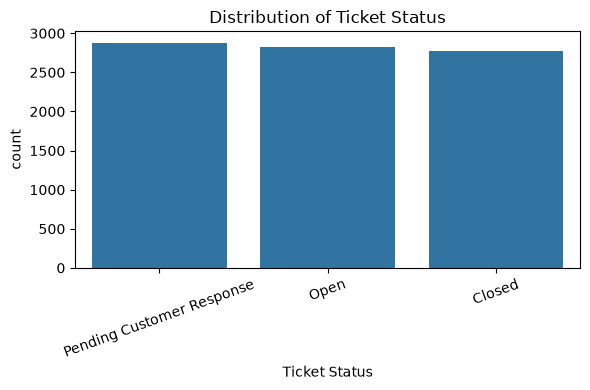

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Ticket Status",
    order=df["Ticket Status"].value_counts().index
)

plt.title("Distribution of Ticket Status")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("images/ticket_status_distribution.png")
plt.show()

In [24]:
X = df["Ticket Description"]
y = df["Ticket Type"]

print(X.head())
print(y.head())

0    I'm having an issue with the {product_purchase...
1    I'm having an issue with the {product_purchase...
2    I'm facing a problem with my {product_purchase...
3    I'm having an issue with the {product_purchase...
4    I'm having an issue with the {product_purchase...
Name: Ticket Description, dtype: str
0    Technical issue
1    Technical issue
2    Technical issue
3    Billing inquiry
4    Billing inquiry
Name: Ticket Type, dtype: str


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6775,)
(1694,)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [27]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.1954


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.12      0.14       357
Cancellation request       0.16      0.17      0.17       327
     Product inquiry       0.21      0.20      0.20       316
      Refund request       0.20      0.24      0.22       345
     Technical issue       0.23      0.25      0.24       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



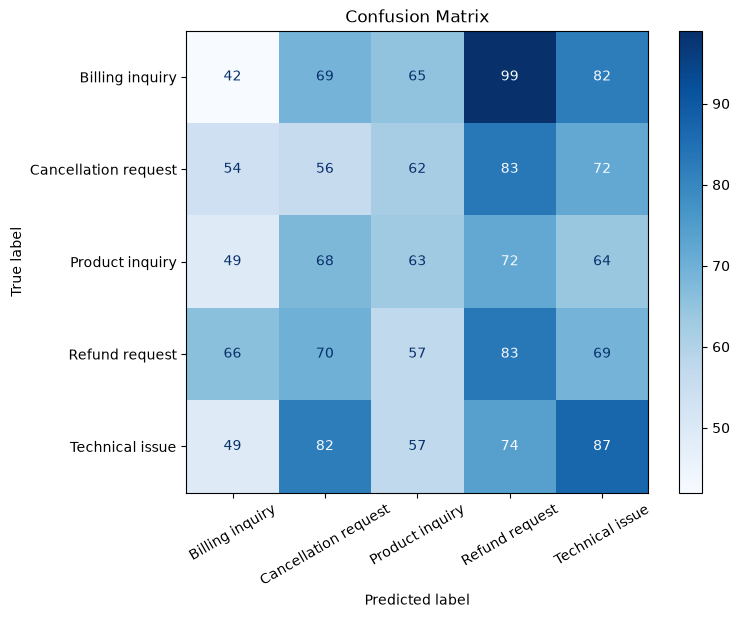

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)

plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

In [32]:
import joblib

joblib.dump(model, "models/support_ticket_classifier.pkl")

print("Model saved!")

Model saved!


In [33]:
new_ticket = [
    "I cannot connect my laptop to the Wi-Fi network."
]

prediction = model.predict(new_ticket)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Billing inquiry


In [34]:
examples = [
    "I would like to cancel my subscription.",
    "Please refund my last payment.",
    "My printer is not working.",
    "I cannot access my account.",
    "The software crashes after the latest update."
]

predictions = model.predict(examples)

for text, pred in zip(examples, predictions):
    print(f"{text}\n -> {pred}\n")

I would like to cancel my subscription.
 -> Billing inquiry

Please refund my last payment.
 -> Technical issue

My printer is not working.
 -> Refund request

I cannot access my account.
 -> Cancellation request

The software crashes after the latest update.
 -> Refund request



In [35]:
print("=" * 40)
print(f"Model Accuracy: {accuracy:.2%}")
print("=" * 40)

Model Accuracy: 19.54%


In [36]:
accuracy_percentage = round(accuracy * 100, 2)

print(accuracy_percentage)

19.54


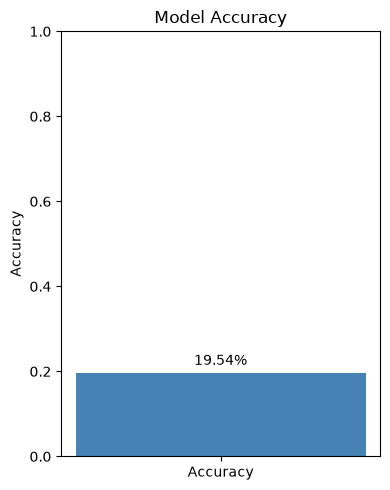

In [37]:
plt.figure(figsize=(4,5))

plt.bar(["Accuracy"], [accuracy], color="steelblue")

plt.ylim(0,1)

plt.title("Model Accuracy")

plt.ylabel("Accuracy")

plt.text(0, accuracy + 0.02, f"{accuracy:.2%}", ha="center")

plt.tight_layout()

plt.savefig("images/model_accuracy.png", dpi=300)

plt.show()